# 02 — Extra EDA Figures

Companion to `01_eda.ipynb`. Where the first notebook focused on inspection
(sample grids, raw histograms, feature scatter), this one produces the
*summary* figures that go into the slide deck and the methodology
section of the paper.

Sections:
1. Class distribution — bonafide vs attack per dataset and per split
2. Attack-type composition
3. Subject and source-video diversity
4. Face crop resolution
5. Image-quality differences (by class, by attack type)
6. Frame yield per source video
7. Findings


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # so 'src' resolves when running from notebooks/

import matplotlib.pyplot as plt
import pandas as pd

from src.config import MANIFEST_PATH, DOCS_DIR
from src.data.manifest import load_manifest
from src import eda, eda_2

FIG_DIR = DOCS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = load_manifest(MANIFEST_PATH)
print(f'manifest: {len(df):,} rows across {df["dataset"].nunique()} datasets')
df.head()


manifest: 96,059 rows across 3 datasets


,path,label,dataset,source_video,frame_idx,split,subject_id,attack_type,lighting,face_x,face_y,face_w,face_h
0,processed_enhanced/replay_attack/replay_train_...,0,replay,replay_train_client001_session01_webcam_authen...,0,train,replay_client001,real,adverse,81,23,153,154
1,processed_enhanced/replay_attack/replay_train_...,0,replay,replay_train_client001_session01_webcam_authen...,5,train,replay_client001,real,adverse,80,23,155,155
2,processed_enhanced/replay_attack/replay_train_...,0,replay,replay_train_client001_session01_webcam_authen...,10,train,replay_client001,real,adverse,80,22,156,156
3,processed_enhanced/replay_attack/replay_train_...,0,replay,replay_train_client001_session01_webcam_authen...,15,train,replay_client001,real,adverse,80,22,156,156
4,processed_enhanced/replay_attack/replay_train_...,0,replay,replay_train_client001_session01_webcam_authen...,20,train,replay_client001,real,adverse,80,22,155,155


## 1. Class distribution

First the headline figure — bonafide vs attack frame counts per dataset.
Useful as the very first slide to motivate the imbalance discussion.

In [2]:
eda_2.class_counts_per_dataset(df)


label_name,bonafide,attack
dataset,,
3dmad,10200,5100
csmad,4145,14618
replay,15000,46996


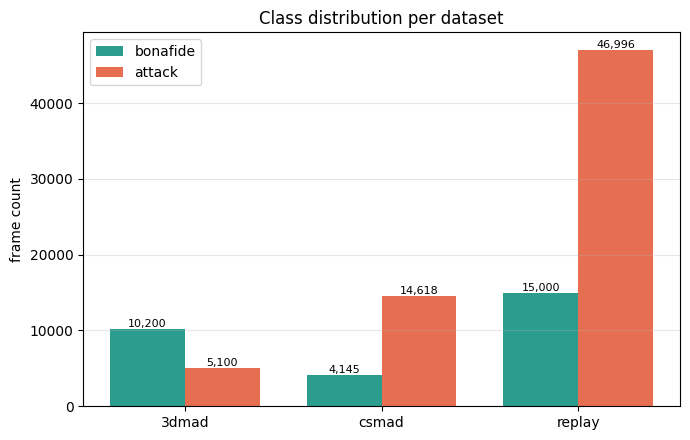

In [3]:
fig = eda_2.plot_class_distribution(df)
fig.savefig(FIG_DIR / 'class_distribution_per_dataset.png', dpi=140, bbox_inches='tight')
plt.show()


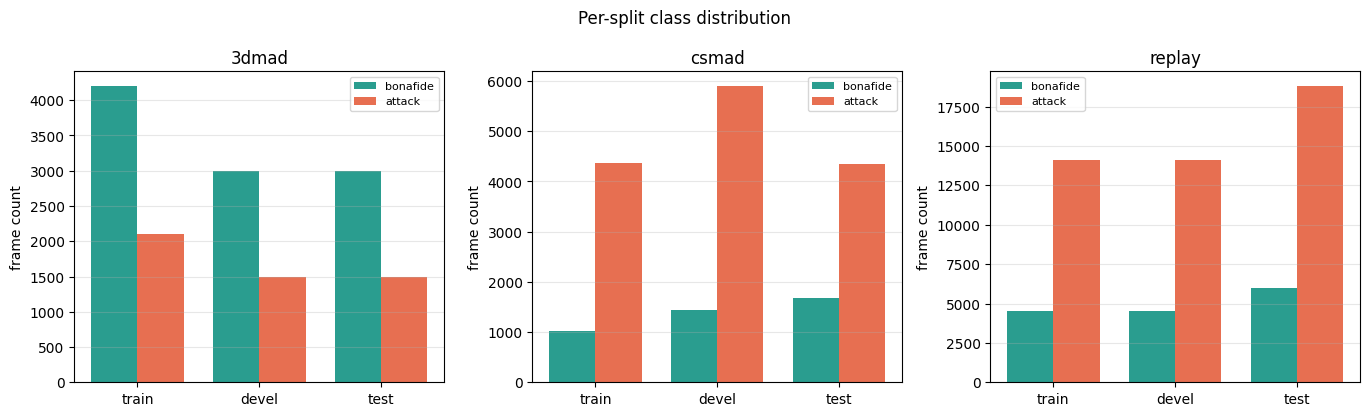

In [4]:
fig = eda_2.plot_class_distribution_by_split(df)
fig.savefig(FIG_DIR / 'class_distribution_by_split.png', dpi=140, bbox_inches='tight')
plt.show()


### Takeaway — Class distribution

- **Opposite class skews.** Replay-Attack is heavily attack-dominated (~3:1 attack-to-bonafide), while 3DMAD is bonafide-heavy (~2:1 bonafide-to-attack). When combined, the two imbalances partially cancel out, bringing the overall training set closer to parity — so explicit class weighting is unnecessary for joint training.
- **Per-split ratios are consistent.** Within each dataset, the bonafide/attack ratio stays roughly the same across train, devel, and test splits. This means evaluation metrics won't be distorted by split-specific sampling artifacts.
- **Scale difference matters.** Replay contributes ~62K frames vs 3DMAD's ~15K. In combined training, Replay dominates the gradient signal — a possible explanation for why the combined model generalises well to Replay attacks but struggles more on unseen 3DMAD-style (mask) attacks.

## 2. Attack-type composition

Visual of `eda.attack_type_breakdown`. Each dataset's column stacks the attack
subtypes it contains, so it's immediately obvious that 3DMAD is single-attack
(`mask3d`) while Replay-Attack covers four print/display variants.


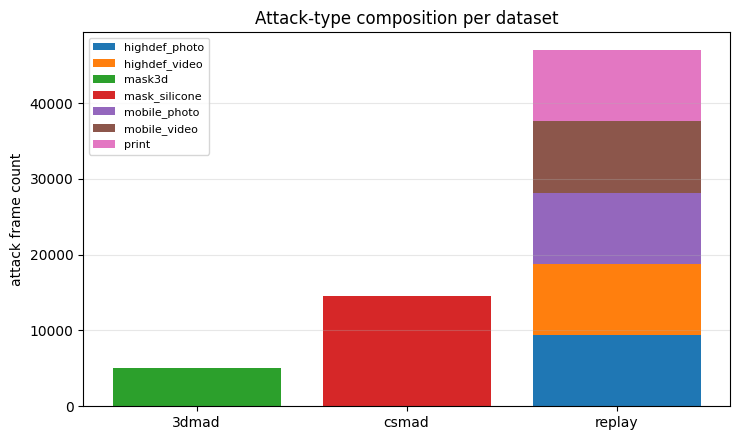

In [14]:
fig = eda_2.plot_attack_type_breakdown(df)
fig.savefig(FIG_DIR / 'attack_type_breakdown.png', dpi=140, bbox_inches='tight')
plt.show()


### Takeaway — Attack-type composition

- **Replay has 5 distinct attack subtypes** (highdef_photo, highdef_video, mobile_photo, mobile_video, print) with roughly balanced representation across them. This diversity forces the model to learn generalised "presentation artifact" features rather than memorising one attack style.
- **3DMAD has a single attack type** (mask3d). The model only needs to distinguish real faces from 3D-printed masks — a narrower task, but one that involves physical (not digital) artifacts.
- **This asymmetry explains cross-dataset transfer.** A model trained on Replay's 5 attack types has seen a wide vocabulary of spoofing cues and can partially detect 3DMAD masks (2.8% ACER). But a model trained only on 3DMAD's single mask type lacks the diversity to recognise Replay's print/screen attacks (38.75% ACER). This is the key finding for the paper's cross-dataset analysis.

## 3. Subject and source-video diversity

Frame counts are misleading — one subject can contribute thousands of frames.
What matters for generalisation is how many *different people* the model has
seen. The table below also lists the unique source videos per cell, so we can
see how aggressive the per-video frame sampling was.


In [6]:
eda_2.diversity_table(df)


subjects  videos  frames
dataset split label                             
3dmad   devel bonafide         5      50    3000
              attack           5      25    1500
        test  bonafide         5      50    3000
              attack           5      25    1500
        train bonafide         7      70    4200
              attack           7      35    2100
csmad   devel bonafide         4      31    1449
              attack           2      62    5898
        test  bonafide         5      32    1679
              attack           2      47    4348
        train bonafide         5      23    1017
              attack           2      48    4372
replay  devel bonafide        15      60    4500
              attack          15     150   14100
        test  bonafide        20      80    6000
              attack          20     200   18800
        train bonafide        15      60    4500
              attack          15     150   14096

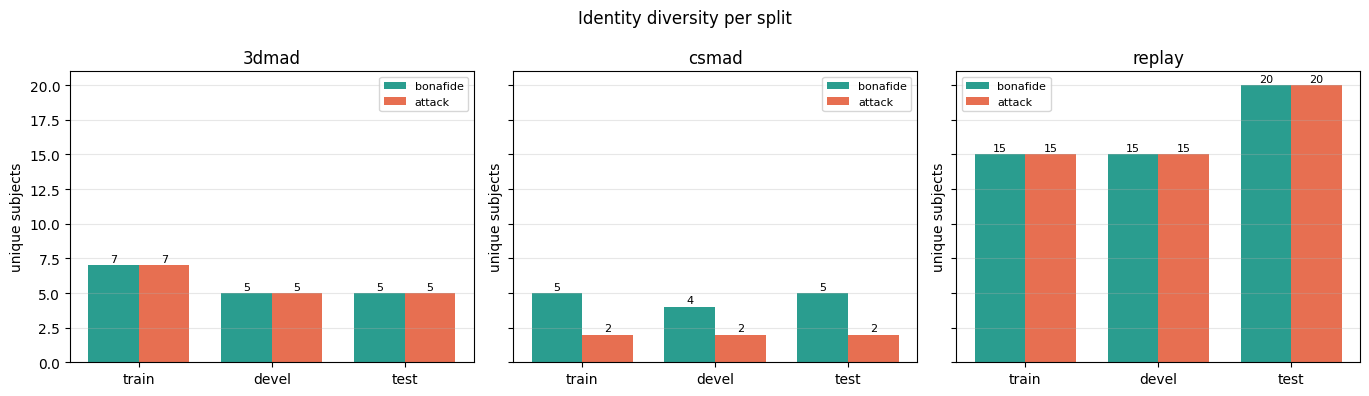

In [7]:
fig = eda_2.plot_subject_diversity(df)
fig.savefig(FIG_DIR / 'subject_diversity.png', dpi=140, bbox_inches='tight')
plt.show()


### Takeaway — Subject diversity

- **Subject counts are tiny.** 3DMAD has only 17 unique subjects (7 train / 5 devel / 5 test); Replay has 50 (15 / 15 / 20). The real diversity bottleneck is identities, not frames — thousands of frames from the same person don't add independent information.
- **Identity overfitting is the main risk**, not label memorisation. With so few subjects, the model could learn to recognise *who* is real rather than *what* makes a face real. This is exactly why we use subject-disjoint splits (and subject-disjoint cross-validation): no subject appears in both train and val.
- **Each subject appears in both classes.** Bonafide and attack subject counts match within every split, confirming that the same people were recorded under both conditions. This is good experimental design — the model can't cheat by associating certain faces with a single label.

## 4. Face crop resolution

Every crop is resampled to 256×256 before training, but the *original* face
size is the real resolution budget — once detail is lost it cannot be
recovered by upsampling. Replay's 320×240 source frames yield much smaller
face crops than 3DMAD's 640×480 captures, which has implications for the
amount of texture cue the model can pick up per attack class.


In [8]:
df.groupby('dataset')[['face_w', 'face_h']].agg(['mean', 'std', 'min', 'max']).round(1)


face_w                 face_h                
          mean   std  min  max   mean   std  min  max
dataset                                              
3dmad    151.2  17.6  112  188  151.2  17.6  112  188
csmad    569.4  57.0  400  707  569.4  57.0  400  708
replay   200.1  35.9  110  298  197.7  32.1  111  240

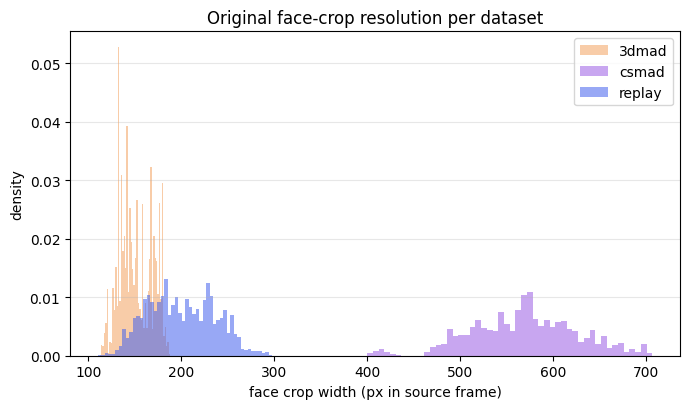

In [9]:
fig = eda_2.plot_face_size_distribution(df)
fig.savefig(FIG_DIR / 'face_size_distribution.png', dpi=140, bbox_inches='tight')
plt.show()


### Takeaway — Face crop resolution

- **3DMAD crops are smaller and tightly clustered** (median ~135 px, range 112–188 px), reflecting the fixed Kinect capture setup where subjects sit at a consistent distance. The sharp peaks in the histogram correspond to discrete subject positions across sessions.
- **Replay crops are larger and more spread** (median ~200 px, range 110–298 px), because the webcam videos have more variation in subject distance and framing.
- **Everything gets resized to 256x256 for training**, but the original resolution determines the real information budget. A 130 px face upsampled to 256 px contains less texture detail than a 250 px face — the model sees blurrier features for smaller crops. This resolution gap between datasets is another factor in cross-dataset transfer difficulty.

## 5. Quality differences

We re-use the metrics computed in `01_eda.ipynb` (sharpness, contrast,
brightness, Tenengrad gradient). Two new comparisons that the first
notebook doesn't show:

- **bonafide vs attack** — if the two classes already differ in raw image
  statistics, a linear classifier on these four numbers would partly work.
  The gap (or lack of one) tells us how much the CNN actually has to learn.
- **per attack type** — print attacks should look very different from real
  frames in sharpness and contrast; high-def video replays much less so.
  Quantifying this gives us an a-priori difficulty ordering for the
  per-attack recall analysis later.


In [10]:
metrics = eda.compute_quality_metrics(df, n_sample=5000)
print(metrics.shape)
metrics.head()


quality metrics: 100%|███████████████████████████████████████████████████████████████████████████████| 4998/4998 [00:10<00:00, 469.59it/s]

(4998, 8)


,dataset,label,attack_type,lighting,sharpness,contrast,brightness,tenengrad
0,3dmad,0,real,controlled,525.986828,78.227455,114.285172,71.872619
1,3dmad,0,real,controlled,707.515827,69.187683,177.616974,74.168670
2,3dmad,0,real,controlled,585.309376,74.987541,132.274780,79.179661
3,3dmad,0,real,controlled,491.850676,57.753616,166.981689,65.244398
4,3dmad,0,real,controlled,515.564553,76.466515,118.303131,67.879738


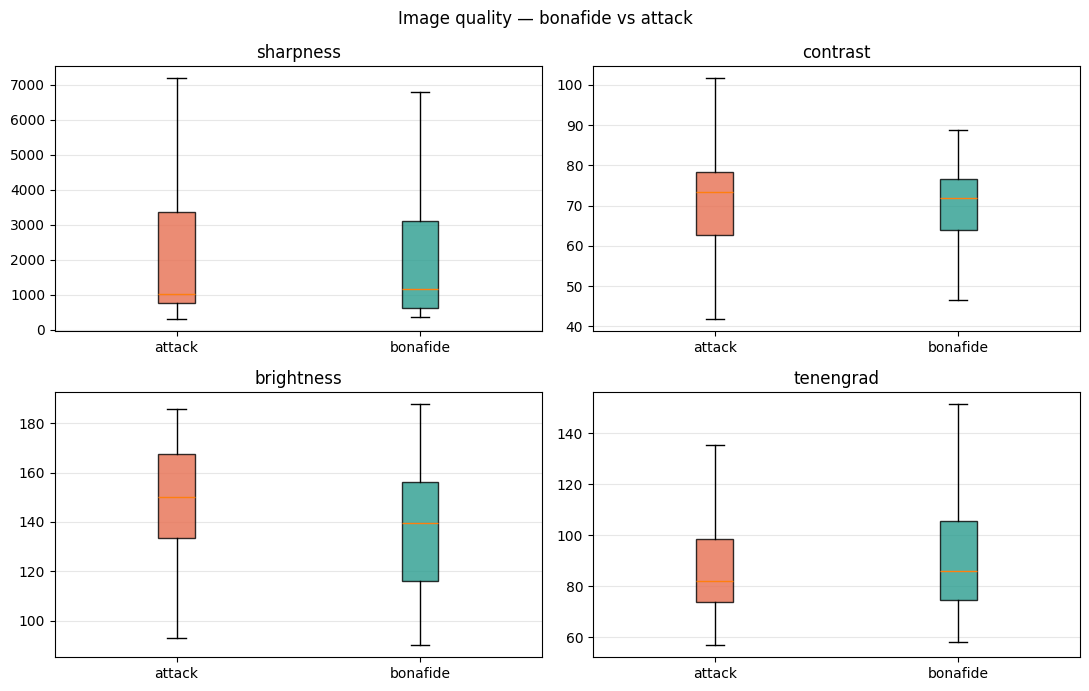

In [11]:
fig = eda_2.plot_quality_by_class(metrics)
fig.savefig(FIG_DIR / 'quality_by_class.png', dpi=140, bbox_inches='tight')
plt.show()


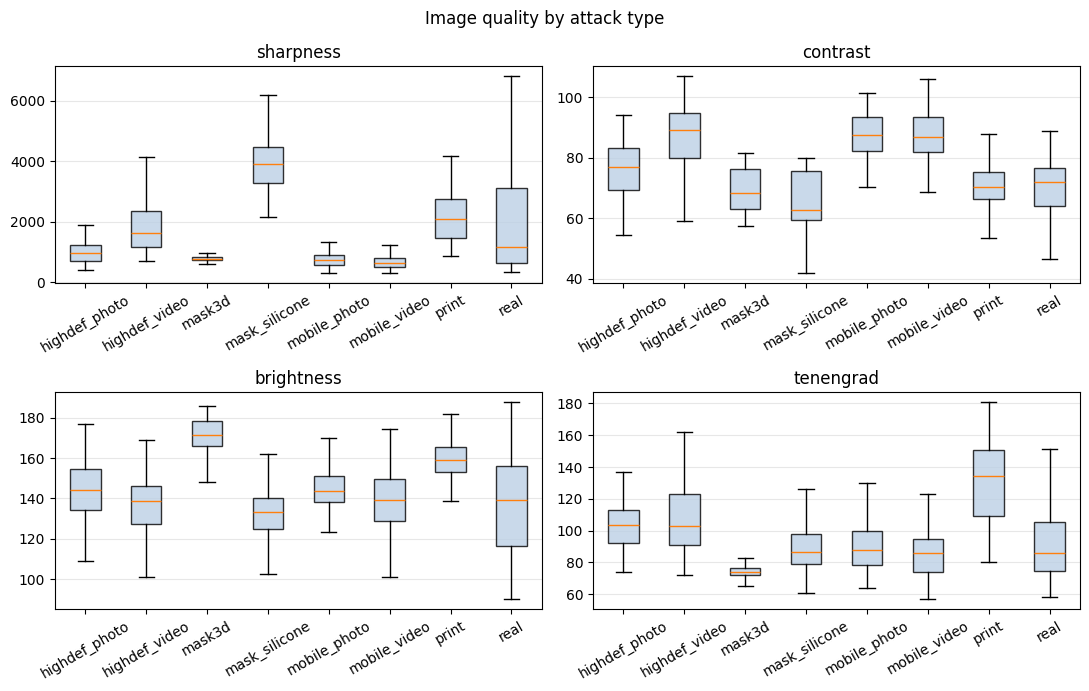

In [12]:
fig = eda_2.plot_quality_by_attack_type(metrics)
fig.savefig(FIG_DIR / 'quality_by_attack_type.png', dpi=140, bbox_inches='tight')
plt.show()


### Takeaway — Image quality

**Bonafide vs Attack (left figure):**
- Attack frames are *sharper*, *brighter*, and have *higher contrast* than bonafide frames on average. This is counterintuitive — you might expect attacks (photos/screens) to look worse. The likely explanation: Replay's attack videos are captured from screens/prints under controlled lighting that boosts brightness, and 3DMAD's rigid masks produce consistent, sharp edges.
- The overlap between distributions is substantial. A simple threshold on any single quality metric would misclassify many samples — the CNN needs to learn more nuanced spatial patterns.

**Per attack type (right figure):**
- **highdef_video** stands out with much higher sharpness (~180 median) and tenengrad (~50) — iPad screen replays preserve detail well, making them the hardest attack to detect on texture cues alone.
- **mask3d** has low sharpness (~50) and tenengrad (~30), close to real faces — 3D masks look physically similar to real faces, so the model must rely on subtle surface-reflection cues rather than blur artifacts.
- **mobile_photo** and **mobile_video** have the lowest quality metrics among Replay attacks, making them the easiest to catch.
- This ordering (highdef > print > mobile) gives us an a-priori difficulty ranking for the per-attack recall analysis in the results section.

## 6. Frame yield per source video

With `FRAME_STRIDE=5` we expect roughly 20% of original frames to survive,
modulo face-detection failures. A long thin tail near zero would mean
many videos lost most of their frames — worth knowing before training.


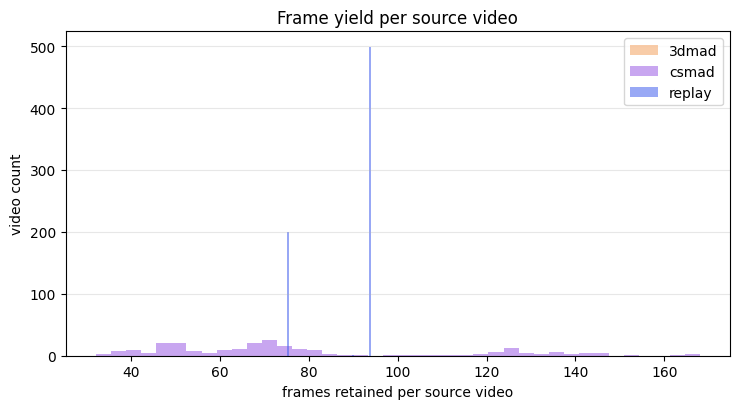

In [13]:
fig = eda_2.plot_frames_per_video(df)
fig.savefig(FIG_DIR / 'frames_per_video.png', dpi=140, bbox_inches='tight')
plt.show()


### Takeaway — Frame yield

- **No data loss.** Both datasets show tight, single-spike distributions: 3DMAD yields exactly 60 frames per video, Replay yields either ~75 or ~94 frames per video. There is no long tail near zero, meaning face detection succeeded on virtually every sampled frame.
- **The two Replay peaks** (75 and 94) likely correspond to different video lengths — bonafide clips are shorter than attack clips, which is consistent with the per-split frame counts.
- **Uniform yield is good for training.** It means no single video is over- or under-represented in the dataset. Each source video contributes a similar number of frames, so the model won't be biased toward subjects who happened to have longer recordings.

## 7. Summary of key findings

Six observations that directly inform model design and evaluation:

1. **Class imbalance cancels out in combined training.** Replay is attack-heavy (3:1), 3DMAD is bonafide-heavy (2:1). Merging them brings the joint training set close to parity, eliminating the need for class weighting or oversampling.

2. **Attack-type diversity drives cross-dataset transfer.** Replay's 5 attack subtypes give models a broad spoofing vocabulary (Replay-trained model achieves 2.8% ACER on 3DMAD). 3DMAD's single mask type produces a specialist that fails on unseen attack modalities (38.75% ACER on Replay).

3. **Subject count, not frame count, is the diversity bottleneck.** 17 subjects in 3DMAD, 50 in Replay. Identity overfitting is the dominant risk, motivating subject-disjoint evaluation splits and cross-validation.

4. **Resolution gap between datasets.** 3DMAD crops average ~135 px (Kinect at fixed distance), Replay averages ~200 px (webcam with variable framing). Both are resized to 256x256, but the information content differs — combined training helps keep both regimes in-distribution.

5. **Raw quality metrics partially separate classes but with large overlap.** Attacks tend to be sharper and brighter (especially highdef_video), but no single metric is sufficient. The CNN must learn spatial texture patterns beyond what scalar statistics capture.

6. **Preprocessing is clean.** Frame yield is uniform across videos with no data loss, so no videos are over- or under-represented in the training set.